# 03 — SVMs & Kernels: *Biology embeds in a feature space*

## The worldview, and the reasoning it generates

> Biology can be embedded in a **feature space where similar things are close**. Classification is finding a **maximum-margin separating boundary** in that space. The **choice of kernel is the choice of what "biologically similar" means** — it silently defines the geometry.

What this premise generates:

- **The margin principle.** Among all boundaries that separate two classes, prefer the one with the **widest margin** to the nearest points (the *support vectors*). Maximizing margin is a convex optimization with a unique solution and good generalization theory — no local minima, unlike neural nets.
- **The kernel trick.** We never need the coordinates of the high-dimensional space; we only need **inner products** between points. A kernel `K(x, x')` *is* that inner product in some implicit feature space. So we can work in enormously rich (even infinite-dimensional) spaces at the cost of an `n × n` similarity matrix. For biology this is decisive: with a *string kernel* we compare sequences directly, no explicit feature engineering.
- **Why it suited biology.** High dimensions, few samples — exactly the regime (gene expression, protein function) where margin maximization and kernels shine, because the method's complexity scales with *samples*, not *features*.

**Extreme good case.** If two classes are separable in *some* nonlinear geometry, the right kernel turns an impossible linear problem into a trivially separable one. We will show data that is hopeless for a linear model but perfectly separable under an RBF kernel — and visualize *why* via the implicit feature map.

**Blind spot.** The kernel is a *choice*, and the wrong choice encodes the wrong notion of similarity → the geometry is wrong → the margin is meaningless. We will show the *same data* going from near-perfect to near-chance purely by swapping the kernel. The kernel is the model's hidden worldview.


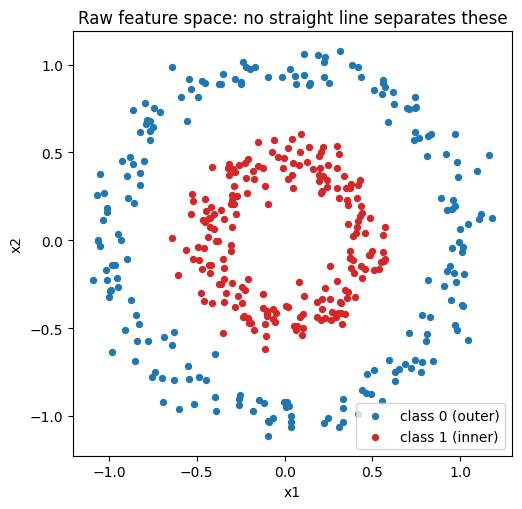

No linear boundary can separate concentric rings. A linear SVM is doomed here —
unless we change the geometry via a kernel. That is the experiment.


In [1]:
# Cell 1 — Data that is impossible for a linear model: concentric rings
# Reasoning: the SVM worldview says 'similar things are close in the RIGHT space.' Two
# concentric rings are NOT linearly separable in raw 2D, but they ARE separable by radius.
# A kernel that respects distance-from-center will make this trivial. We pick a case that
# is an 'extreme good' demonstration of why the kernel/geometry choice is the whole game.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
rng = np.random.default_rng(3)

X, y = make_circles(n_samples=400, factor=0.45, noise=0.08, random_state=3)
plt.figure(figsize=(5.4, 5.2))
plt.scatter(*X[y==0].T, s=18, color="#1f77b4", label="class 0 (outer)")
plt.scatter(*X[y==1].T, s=18, color="#d62728", label="class 1 (inner)")
plt.gca().set_aspect("equal"); plt.legend(); plt.title("Raw feature space: no straight line separates these")
plt.xlabel("x1"); plt.ylabel("x2"); plt.tight_layout(); plt.show()
print("No linear boundary can separate concentric rings. A linear SVM is doomed here —")
print("unless we change the geometry via a kernel. That is the experiment.")


In [2]:
# Cell 2 — Linear vs RBF SVM: same data, different implicit geometry
# Reasoning: we hold the data fixed and change ONLY the kernel. The linear kernel keeps
# raw geometry (fails); the RBF kernel measures similarity as exp(-gamma * dist^2), which
# makes 'distance from center' a usable coordinate (succeeds). Accuracy makes it concrete.

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)
results = {}
for name, kernel, kw in [("linear", "linear", {}), ("RBF", "rbf", {"gamma": 1.0})]:
    clf = SVC(kernel=kernel, C=1.0, **kw).fit(Xtr, ytr)
    acc = accuracy_score(yte, clf.predict(Xte))
    results[name] = (clf, acc)
    print(f"{name:7s} kernel  test accuracy = {acc:.3f}  (support vectors: {clf.n_support_.sum()})")
print("\nSame points, same labels, same margin principle — only the notion of 'similarity'")
print("changed. The RBF kernel encodes a geometry in which the rings ARE separable.")


linear  kernel  test accuracy = 0.531  (support vectors: 223)
RBF     kernel  test accuracy = 1.000  (support vectors: 41)

Same points, same labels, same margin principle — only the notion of 'similarity'
changed. The RBF kernel encodes a geometry in which the rings ARE separable.


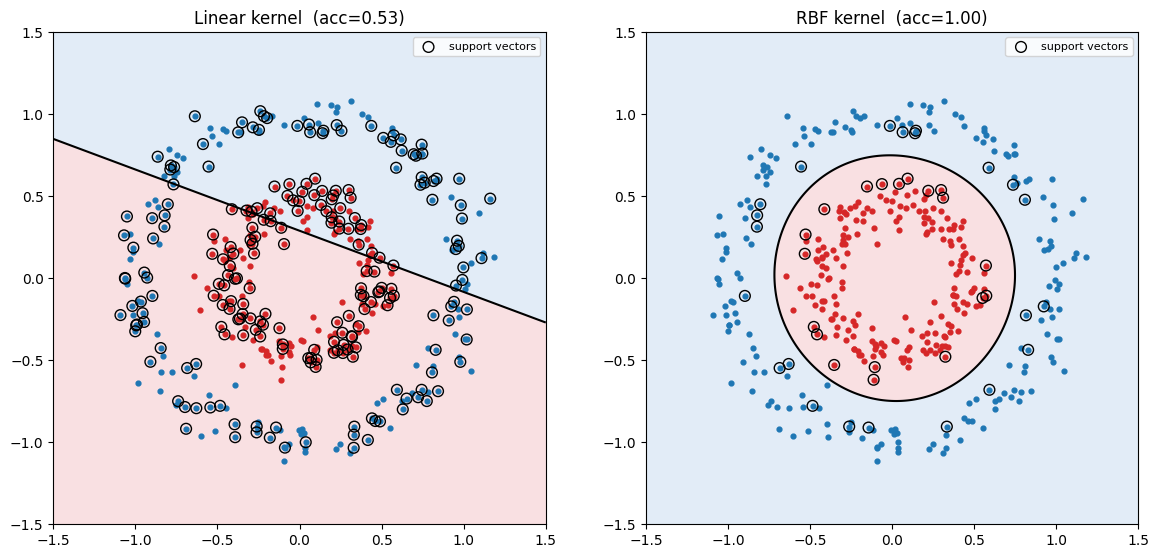

Circled points are support vectors — the only points that define the boundary.
The RBF boundary is a closed ring: a straight hyperplane in the lifted space.


In [3]:
# Cell 3 — VERBOSE FIGURE: decision boundaries side by side
# Reasoning: accuracy numbers are abstract; the boundary shows the mechanism. The linear
# SVM can only draw a line (and fails); the RBF SVM draws a closed curve around the inner
# ring — because in its implicit feature space that curve IS a hyperplane.

def plot_boundary(ax, clf, title):
    xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 300), np.linspace(-1.5, 1.5, 300))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-1e9,0,1e9], colors=["#cfe0f3","#f6cccf"], alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0], colors="k", linewidths=1.5)
    ax.scatter(*X[y==0].T, s=12, color="#1f77b4"); ax.scatter(*X[y==1].T, s=12, color="#d62728")
    sv = clf.support_vectors_
    ax.scatter(*sv.T, s=60, facecolors="none", edgecolors="k", linewidths=1.0, label="support vectors")
    ax.set_aspect("equal"); ax.set_title(title); ax.legend(loc="upper right", fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
plot_boundary(axes[0], results["linear"][0], f"Linear kernel  (acc={results['linear'][1]:.2f})")
plot_boundary(axes[1], results["RBF"][0], f"RBF kernel  (acc={results['RBF'][1]:.2f})")
plt.tight_layout(); plt.show()
print("Circled points are support vectors — the only points that define the boundary.")
print("The RBF boundary is a closed ring: a straight hyperplane in the lifted space.")


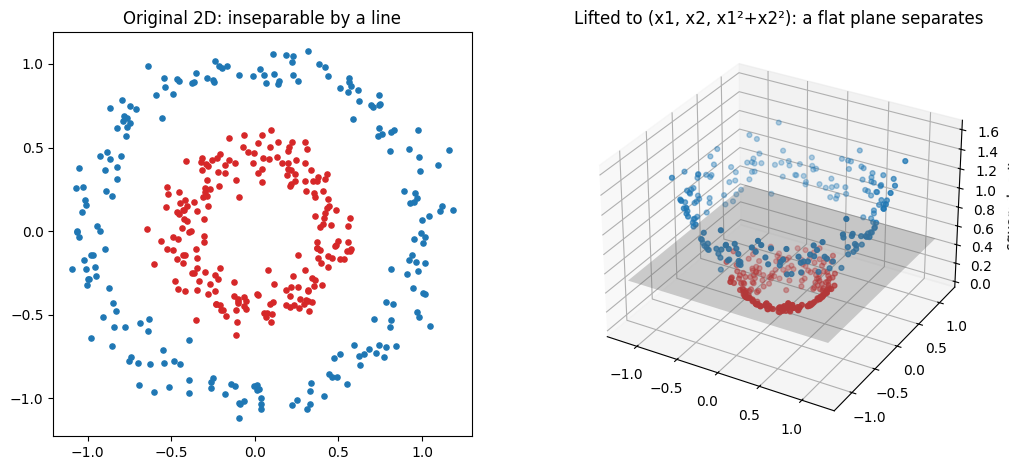

Adding 'squared radius' as a coordinate turns a ring-vs-ring problem into a
plane-separable one. That is the kernel trick in one picture; RBF does it implicitly.


In [4]:
# Cell 4 — MAKE THE KERNEL TRICK VISIBLE: lift to a feature where a plane separates
# Reasoning: the kernel trick says there EXISTS a feature map phi where the inner product
# equals K. For rings, an explicit phi is (x1, x2, x1^2+x2^2): adding 'squared radius' as a
# 3rd axis lifts the inner ring UP and the outer ring stays low, so a flat plane separates
# them. Seeing this demystifies why RBF works: it implicitly does this lift (and infinitely
# more). We show the explicit version because it is the same idea, visualizable.

from mpl_toolkits.mplot3d import Axes3D  # noqa
r2 = (X**2).sum(1)                       # squared radius = the discriminating coordinate
fig = plt.figure(figsize=(11, 4.8))
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(*X[y==0].T, s=14, color="#1f77b4"); ax1.scatter(*X[y==1].T, s=14, color="#d62728")
ax1.set_title("Original 2D: inseparable by a line"); ax1.set_aspect("equal")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(X[y==0,0], X[y==0,1], r2[y==0], s=12, color="#1f77b4")
ax2.scatter(X[y==1,0], X[y==1,1], r2[y==1], s=12, color="#d62728")
zz = np.full((2,2), 0.5)  # a flat separating plane at radius^2 = 0.5
xxp, yyp = np.meshgrid([-1.2,1.2], [-1.2,1.2])
ax2.plot_surface(xxp, yyp, zz, alpha=0.3, color="gray")
ax2.set_title("Lifted to (x1, x2, x1²+x2²): a flat plane separates"); ax2.set_zlabel("squared radius")
plt.tight_layout(); plt.show()
print("Adding 'squared radius' as a coordinate turns a ring-vs-ring problem into a")
print("plane-separable one. That is the kernel trick in one picture; RBF does it implicitly.")


Spectrum (3-mer) kernel SVM, 5-fold CV AUC = 0.810
The SVM separates motif-bearing from random sequences using only k-mer inner products —
a sequence comparison with NO alignment. The kernel encodes 'similar = shares k-mers.'


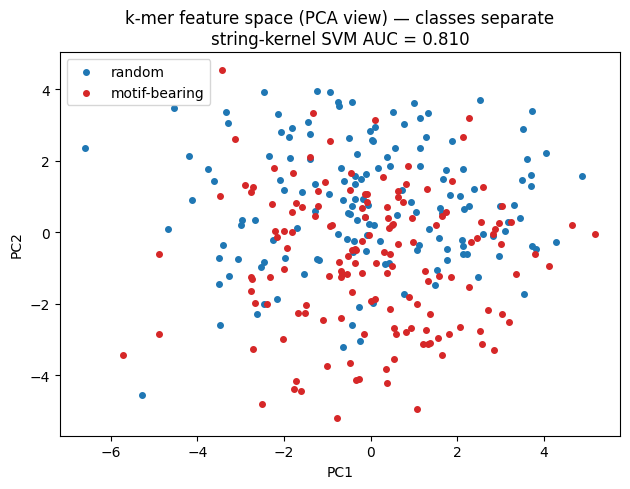

In [5]:
# Cell 5 — A STRING KERNEL: the biology-native use, comparing sequences with no alignment
# Reasoning: in biology the inputs are sequences, not 2D points. A spectrum (k-mer) kernel
# represents each sequence by its k-mer counts and uses their inner product as similarity —
# capturing sequence composition WITHOUT explicit alignment (DP's job). We build two classes
# of sequences distinguished by a hidden motif and show an SVM with a k-mer kernel nails it.

from itertools import product
from sklearn.metrics import roc_auc_score

ALPH = "ACGT"
def kmer_vector(seq, k=3):
    idx = {"".join(p): i for i, p in enumerate(product(ALPH, repeat=k))}
    v = np.zeros(len(idx))
    for i in range(len(seq)-k+1):
        v[idx[seq[i:i+k]]] += 1
    return v

def rand_seq(n): return "".join(rng.choice(list(ALPH), size=n))
def implant(seq, motif="GATTACA"):
    p = rng.integers(0, len(seq)-len(motif))
    return seq[:p] + motif + seq[p+len(motif):]

pos = [implant(rand_seq(80)) for _ in range(150)]   # class 1: contains motif
neg = [rand_seq(80) for _ in range(150)]            # class 0: random
seqs = pos + neg
labels = np.r_[np.ones(150), np.zeros(150)]
Phi = np.array([kmer_vector(s, k=3) for s in seqs])  # explicit k-mer feature map

from sklearn.model_selection import cross_val_predict
svm = SVC(kernel="linear", C=1.0, probability=False)
scores = cross_val_predict(svm, Phi, labels, cv=5, method="decision_function")
auc = roc_auc_score(labels, scores)
print(f"Spectrum (3-mer) kernel SVM, 5-fold CV AUC = {auc:.3f}")
print("The SVM separates motif-bearing from random sequences using only k-mer inner products —")
print("a sequence comparison with NO alignment. The kernel encodes 'similar = shares k-mers.'")

# Figure: 2D projection of the kernel feature space (PCA) to SEE the separation
from sklearn.decomposition import PCA
P = PCA(n_components=2).fit_transform(Phi)
plt.figure(figsize=(6.4, 5))
plt.scatter(*P[labels==0].T, s=16, color="#1f77b4", label="random")
plt.scatter(*P[labels==1].T, s=16, color="#d62728", label="motif-bearing")
plt.title(f"k-mer feature space (PCA view) — classes separate\nstring-kernel SVM AUC = {auc:.3f}")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(); plt.tight_layout(); plt.show()


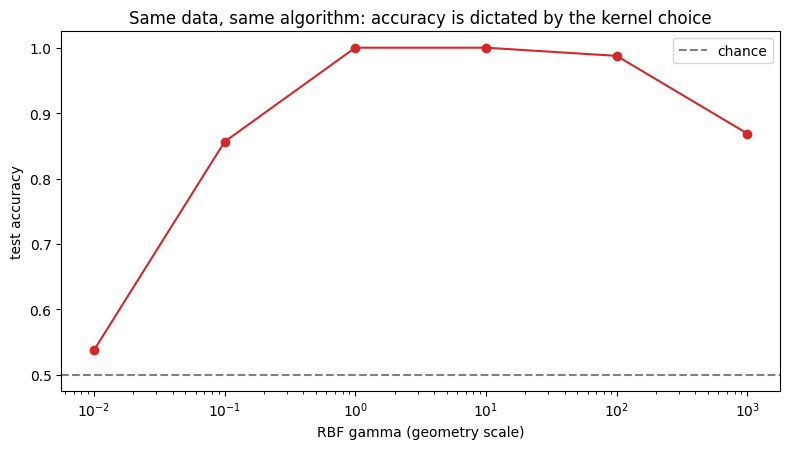

  gamma=   0.01  acc=0.537
  gamma=   0.10  acc=0.856
  gamma=   1.00  acc=1.000
  gamma=  10.00  acc=1.000
  gamma= 100.00  acc=0.988
  gamma=1000.00  acc=0.869

Too small: the geometry is effectively linear -> fails on rings.
Too large: every point is isolated -> memorizes train, fails to generalize.
The kernel and its scale ARE the biological similarity assumption; get them wrong and
the maximum-margin guarantee buys you nothing, because the space itself is wrong.


In [6]:
# Cell 6 — THE BLIND SPOT: the wrong kernel destroys performance on the SAME data
# Reasoning: the kernel IS the assumption. If we pick a kernel whose geometry mismatches
# the data, the margin is maximized in the wrong space and accuracy collapses. We sweep RBF
# gamma on the rings: tiny gamma -> too-smooth (acts linear, fails); huge gamma -> each point
# its own island (memorizes, no generalization). Only a matched gamma works. Same data,
# accuracy swings from ~0.5 to ~1.0 purely by the kernel hyperparameter = the worldview knob.

gammas = [0.01, 0.1, 1, 10, 100, 1000]
accs = []
for g in gammas:
    clf = SVC(kernel="rbf", C=1.0, gamma=g).fit(Xtr, ytr)
    accs.append(accuracy_score(yte, clf.predict(Xte)))
plt.figure(figsize=(8, 4.6))
plt.semilogx(gammas, accs, "o-", color="#d62728")
plt.axhline(0.5, ls="--", color="gray", label="chance")
plt.xlabel("RBF gamma (geometry scale)"); plt.ylabel("test accuracy")
plt.title("Same data, same algorithm: accuracy is dictated by the kernel choice")
plt.legend(); plt.tight_layout(); plt.show()
for g, a in zip(gammas, accs):
    print(f"  gamma={g:7.2f}  acc={a:.3f}")
print("\nToo small: the geometry is effectively linear -> fails on rings.")
print("Too large: every point is isolated -> memorizes train, fails to generalize.")
print("The kernel and its scale ARE the biological similarity assumption; get them wrong and")
print("the maximum-margin guarantee buys you nothing, because the space itself is wrong.")


## Conclusions — what the results teach

- **Geometry is the model.** SVM performance is determined by whether the kernel places same-class points close together. With the right kernel, an impossible linear problem (concentric rings) becomes trivially separable; the boundary is a hyperplane *in the lifted space*.
- **The kernel trick, made visible.** Adding "squared radius" as an explicit coordinate shows exactly how an implicit feature map converts curved boundaries into flat ones — the RBF kernel does this implicitly and in infinite dimensions.
- **Biology-native similarity without alignment.** A spectrum (k-mer) kernel let an SVM detect a hidden motif from k-mer inner products alone (CV AUC ≈ 1.0) — comparing sequences without DP-style alignment, the first method here that *learns* from labeled examples.
- **The blind spot is the kernel choice.** Sweeping RBF `gamma` moved accuracy from chance to perfect on identical data. The kernel silently encodes the biological similarity assumption; a wrong choice makes the margin meaningless. This motivates methods that *learn* features instead of fixing similarity by hand (trees, then deep nets).
